In [ ]:
# =============================================================================
# 第4章：多层感知机 - 激活函数对比
# =============================================================================
# 本节可视化三种最常用的激活函数：ReLU、Sigmoid、Tanh
# 理解它们的特性对设计神经网络至关重要

%matplotlib inline
import torch
from d2l import torch as d2l


# =============================================================================
# ReLU (Rectified Linear Unit) - 整流线性单元
# =============================================================================
# 公式：f(x) = max(0, x)
# 特点：
#   - 正区间：梯度恒为1，缓解梯度消失
#   - 负区间：输出为0，神经元"死亡"（不再更新）
#   - 计算简单，没有指数运算
# 
# 为什么成为默认选择：
# 1. 生物神经元激活的近似
# 2. 解决了Sigmoid的梯度消失问题
# 3. 计算效率极高

# 创建输入张量，requires_grad=True 用于后续计算梯度
# 范围从-8到8，步长0.1，覆盖激活函数的完整定义域
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)

# 应用ReLU激活函数
y = torch.relu(x)

# 绘制ReLU函数图像
# 形状：在x<0时为0，x>0时为斜率为1的直线
# 在x=0处不可导（实际实现中通常取左导数或右导数）
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize=(5, 2.5))


# =============================================================================
# Sigmoid 函数
# =============================================================================
# 公式：f(x) = 1 / (1 + e^(-x))
# 特点：
#   - 输出范围(0, 1)，可以解释为概率
#   - 平滑可导，处处可微
#   - 两端饱和，导致梯度消失
#
# 梯度推导：
#   f'(x) = f(x) * (1 - f(x))
#   当x很大或很小时，f'(x) ≈ 0

# 重新创建x，因为之前的backward已经释放了计算图
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)

# 绘制Sigmoid函数
# 形状：S型曲线，中心在(0, 0.5)
# 当x→∞时趋近于1，x→-∞时趋近于0
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize=(5, 2.5))


# =============================================================================
# Tanh (Hyperbolic Tangent) - 双曲正切
# =============================================================================
# 公式：f(x) = (e^x - e^(-x)) / (e^x + e^(-x))
# 特点：
#   - 输出范围(-1, 1)，零中心化（输出均值为0）
#   - 相比Sigmoid，梯度范围更大（最大梯度为1 vs 0.25）
#   - 仍存在两端饱和问题
#
# 与Sigmoid的关系：
#   tanh(x) = 2 * sigmoid(2x) - 1

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.tanh(x)

# 绘制Tanh函数
# 形状：S型曲线，中心在原点
# 当x→∞时趋近于1，x→-∞时趋近于-1
d2l.plot(x.detach(), y.detach(), 'x', 'tanh(x)', figsize=(5, 2.5))

In [ ]:
# =============================================================================
# 多层感知机（MLP）手动实现
# =============================================================================
# 本节从零开始实现一个多层感知机，包含：
# - 一个隐藏层（256个神经元）
# - ReLU激活函数
# - 输出层（10个类别）
# 
# 网络结构：输入(784) → 隐藏层(256) → ReLU → 输出层(10)
#          [全连接]    [全连接+激活]    [全连接]

import torch
from torch import nn
from d2l import torch as d2l


# =============================================================================
# 数据准备
# =============================================================================
# 批量大小：每次迭代使用的样本数
# 较大的batch_size可以更准确估计梯度，但需要更多内存
batch_size = 256

# 加载Fashion-MNIST数据集
# 训练集用于更新参数，测试集用于评估泛化能力
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)


# =============================================================================
# 模型参数定义
# =============================================================================
# 输入维度：28×28=784（图像展平为一维向量）
num_inputs = 784

# 输出维度：10（Fashion-MNIST有10个类别）
num_outputs = 10

# 隐藏层神经元数量：256
# 这是一个超参数，需要根据任务调整
# 隐藏层神经元越多，模型表达能力越强，但也更容易过拟合
num_hiddens = 256


# =============================================================================
# 权重初始化
# =============================================================================
# 第一层权重：从输入到隐藏层
# 形状：(784, 256)，每个输入特征连接到每个隐藏神经元
# 初始化：标准正态分布 × 0.01，使初始值较小，避免梯度爆炸
W1 = nn.Parameter(torch.randn(
    num_inputs, num_hiddens, requires_grad=True) * 0.01)

# 第一层偏置：每个隐藏神经元一个偏置项
# 形状：(256,)，初始化为0
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))

# 第二层权重：从隐藏层到输出
# 形状：(256, 10)
W2 = nn.Parameter(torch.randn(
    num_hiddens, num_outputs, requires_grad=True) * 0.01)

# 第二层偏置：每个输出类别一个偏置项
# 形状：(10,)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

# 将所有参数放入列表，方便优化器统一管理
params = [W1, b1, W2, b2]


# =============================================================================
# 激活函数定义
# =============================================================================
# 手动实现ReLU激活函数
def relu(X):
    """
    ReLU激活函数：保留正数，将负数置为0
    
    参数:
        X: 输入张量，可以是任意形状
    返回:
        与X形状相同的张量，负数位置为0
    """
    # torch.zeros_like(X) 创建与X形状相同的全0张量
    # torch.max 逐元素比较，取较大值
    a = torch.zeros_like(X)
    return torch.max(X, a)


# =============================================================================
# 模型定义
# =============================================================================
def net(X):
    """
    多层感知机前向传播
    
    参数:
        X: 输入张量，形状 (batch_size, 1, 28, 28) 或 (batch_size, 784)
    返回:
        输出张量，形状 (batch_size, 10)
    """
    # 将输入展平为二维：(batch_size, 784)
    # -1 表示自动计算该维度的大小
    X = X.reshape((-1, num_inputs))
    
    # 第一层计算：线性变换 + ReLU激活
    # X @ W1：矩阵乘法，(batch_size, 784) @ (784, 256) = (batch_size, 256)
    # + b1：广播机制，给每个样本的每个隐藏神经元加上偏置
    # relu：应用激活函数，负数置0
    H = relu(X @ W1 + b1)
    
    # 第二层计算：线性变换（输出层不需要激活函数）
    # H @ W2：(batch_size, 256) @ (256, 10) = (batch_size, 10)
    return H @ W2 + b2


# =============================================================================
# 损失函数
# =============================================================================
# 使用交叉熵损失函数，这是多分类任务的标准选择
# reduction='none' 表示不对损失求平均或求和，保留每个样本的损失
# 这样可以在训练时更灵活地处理损失（如加权）
loss = nn.CrossEntropyLoss(reduction='none')


# =============================================================================
# 训练配置
# =============================================================================
num_epochs = 10  # 训练轮数：整个数据集遍历10次
lr = 0.1         # 学习率：控制参数更新的步长

# 使用SGD优化器，传入所有模型参数
# PyTorch的optim.SGD会自动管理参数的梯度更新
updater = torch.optim.SGD(params, lr=lr)


# =============================================================================
# 开始训练
# =============================================================================
# 使用d2l.train_ch3进行训练，它会自动：
# 1. 迭代训练数据
# 2. 计算损失和梯度
# 3. 更新参数
# 4. 评估训练集和测试集精度
# 5. 可视化训练过程
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)


# =============================================================================
# 预测展示
# =============================================================================
# 使用训练好的模型对测试集进行预测
# 可视化前6个样本的预测结果，显示真实标签和预测标签
d2l.predict_ch3(net, test_iter)

In [ ]:
# =============================================================================
# 多层感知机简洁实现
# =============================================================================
# 使用PyTorch的nn.Module API简洁实现MLP
# 对比从零实现，代码更简洁，且利用PyTorch的优化

import torch
from torch import nn
from d2l import torch as d2l


# =============================================================================
# 模型定义（Sequential方式）
# =============================================================================
# nn.Sequential将多个层按顺序组合成一个网络
# 数据会自动依次通过每一层

net = nn.Sequential(
    # 第一层：展平层
    # 将输入从(batch_size, 1, 28, 28)展平为(batch_size, 784)
    # 不需要学习参数，只是改变张量形状
    nn.Flatten(),
    
    # 第二层：全连接层（输入→隐藏层）
    # 784个输入特征，256个输出特征（隐藏神经元）
    # 内部包含权重矩阵W(784,256)和偏置b(256,)
    nn.Linear(784, 256),
    
    # 第三层：ReLU激活函数
    # 逐元素应用ReLU，负数置0
    # 这是一个无参层，只是非线性变换
    nn.ReLU(),
    
    # 第四层：全连接层（隐藏层→输出）
    # 256个输入特征，10个输出特征（类别数）
    nn.Linear(256, 10)
)


# =============================================================================
# 权重初始化
# =============================================================================
# 定义初始化函数，对每一层应用不同的初始化策略
def init_weights(m):
    """
    对网络层进行权重初始化
    
    参数:
        m: 网络中的某一层
    """
    # 只对线性层进行初始化
    if type(m) == nn.Linear:
        # 使用正态分布初始化权重
        # 均值为0，标准差为0.01
        # 偏置默认已经初始化为0
        nn.init.normal_(m.weight, std=0.01)


# 对net的所有层应用init_weights函数
# apply会递归遍历网络的每一层
net.apply(init_weights)


# =============================================================================
# 训练配置
# =============================================================================
batch_size = 256    # 批量大小
lr = 0.1            # 学习率
num_epochs = 10     # 训练轮数

# 交叉熵损失函数
# reduction='none'保留每个样本的损失
loss = nn.CrossEntropyLoss(reduction='none')

# SGD优化器
# net.parameters()返回网络中所有需要学习的参数
# 这比手动管理params列表更方便
trainer = torch.optim.SGD(net.parameters(), lr=lr)


# =============================================================================
# 数据加载
# =============================================================================
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)


# =============================================================================
# 开始训练
# =============================================================================
# 使用相同的train_ch3函数进行训练
# 接口与从零实现完全一致，体现了模块化的设计
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

In [ ]:
# =============================================================================
# 多项式回归：欠拟合与过拟合
# =============================================================================
# 本节通过多项式回归演示模型复杂度的影响：
# - 欠拟合：模型过于简单，无法捕捉数据规律
# - 合适拟合：模型复杂度匹配数据规律
# - 过拟合：模型过于复杂，学习了噪声

import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l


# =============================================================================
# 生成合成数据集
# =============================================================================
# 最大多项式阶数：20
# 我们将从这么多特征中选择子集来演示不同复杂度
max_degree = 20

# 训练集和测试集各100个样本
# 小数据集更容易展示过拟合现象
n_train, n_test = 100, 100

# 真实的权重向量，只有前4个是非零的
# 这意味着真实函数是一个3次多项式
true_w = np.zeros(max_degree)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

# 生成输入特征：从标准正态分布采样
# 形状：(200, 1)，200个样本，每个1维特征
features = np.random.normal(size=(n_train + n_test, 1))

# 随机打乱数据
np.random.shuffle(features)


# =============================================================================
# 构建多项式特征
# =============================================================================
# np.power计算幂次，np.arange生成[0,1,2,...,19]
# 结果形状：(200, 20)，每行是一个样本，每列是不同阶次的特征
# 第i列是原始特征的i次方
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))

# Gamma函数归一化：gamma(n) = (n-1)!
# 将x^n除以n!，防止高阶项数值过大
# 这是泰勒展开中的标准做法
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)


# =============================================================================
# 生成标签
# =============================================================================
# 计算真实值：多项式与权重的线性组合
# 形状：(200,)
labels = np.dot(poly_features, true_w)

# 添加高斯噪声，模拟真实数据
# 噪声标准差0.1，均值0
labels += np.random.normal(scale=0.1, size=labels.shape)


# =============================================================================
# 转换为PyTorch张量
# =============================================================================
# 所有数据转换为float32类型，这是GPU计算的标准格式
true_w, features, poly_features, labels = [
    torch.tensor(x, dtype=torch.float32) 
    for x in [true_w, features, poly_features, labels]
]

# 查看前2个样本的特征和标签
features[:2], poly_features[:2, :], labels[:2]


# =============================================================================
# 评估函数
# =============================================================================
def evaluate_loss(net, data_iter, loss):  #@save
    """
    评估模型在给定数据集上的平均损失
    
    参数:
        net: 神经网络模型
        data_iter: 数据迭代器
        loss: 损失函数
    返回:
        平均损失值
    """
    metric = d2l.Accumulator(2)  # 累加器：损失总和、样本数量
    for X, y in data_iter:
        out = net(X)
        # 确保y的形状与out匹配
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]


# =============================================================================
# 训练函数
# =============================================================================
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    """
    训练多项式回归模型
    
    参数:
        train_features: 训练集特征
        test_features: 测试集特征
        train_labels: 训练集标签
        test_labels: 测试集标签
        num_epochs: 训练轮数
    """
    # 使用均方误差损失
    loss = nn.MSELoss(reduction='none')
    
    # 输入维度由特征数量决定
    input_shape = train_features.shape[-1]
    
    # 定义网络：简单的线性回归（无隐藏层）
    # bias=False因为我们已经在多项式特征中处理了常数项（x^0=1）
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    
    # 批量大小取min(10, 训练样本数)
    # 小批量可以更好地展示训练动态
    batch_size = min(10, train_labels.shape[0])
    
    # 创建数据迭代器
    train_iter = d2l.load_array(
        (train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array(
        (test_features, test_labels.reshape(-1, 1)), batch_size, is_train=False)
    
    # SGD优化器，学习率0.01
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    
    # 动画绘制器，y轴使用对数刻度
    animator = d2l.Animator(
        xlabel='epoch', ylabel='loss', yscale='log',
        xlim=[1, num_epochs], ylim=[1e-3, 1e2],
        legend=['train', 'test'])
    
    # 训练循环
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        # 每20个epoch绘制一次损失曲线
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, 
                        (evaluate_loss(net, train_iter, loss),
                         evaluate_loss(net, test_iter, loss)))
    
    # 打印训练后的权重
    print('weight:', net[0].weight.data.numpy())


# =============================================================================
# 实验1：正常拟合（使用正确的模型复杂度）
# =============================================================================
# 只使用前4个特征：1, x, x^2/2!, x^3/3!
# 这与真实函数（3次多项式）的复杂度匹配
# 预期：训练损失和测试损失都较低且接近
print("=" * 50)
print("实验1：正常拟合（使用4个特征）")
print("=" * 50)
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])


# =============================================================================
# 实验2：欠拟合（模型过于简单）
# =============================================================================
# 只使用前2个特征：1, x
# 这相当于线性模型，无法捕捉3次多项式的非线性
# 预期：训练损失和测试损失都较高
print("\n" + "=" * 50)
print("实验2：欠拟合（使用2个特征）")
print("=" * 50)
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])


# =============================================================================
# 实验3：过拟合（模型过于复杂）
# =============================================================================
# 使用所有20个特征
# 模型复杂度远超真实函数，会学习噪声
# 预期：训练损失很低，但测试损失很高（差距大）
print("\n" + "=" * 50)
print("实验3：过拟合（使用20个特征）")
print("=" * 50)
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

In [ ]:
# =============================================================================
# 权重衰减（L2正则化）
# =============================================================================
# 本节演示如何使用权重衰减（Weight Decay）防止过拟合
# 原理：在损失函数中添加权重的L2范数惩罚，鼓励小权重

%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l


# =============================================================================
# 创建合成数据集
# =============================================================================
# 为了清晰展示过拟合，我们：
# 1. 使用高维特征（200维）
# 2. 使用小样本（训练集20个，测试集100个）
# 这种设置容易导致模型记忆训练数据而不是学习规律

n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5

# 真实的权重和偏置（很小，接近0）
true_w = torch.ones((num_inputs, 1)) * 0.01
true_b = 0.05

# 生成训练和测试数据
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)

test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)


# =============================================================================
# 参数初始化
# =============================================================================
def init_params():
    """
    初始化模型参数
    
    返回:
        [w, b] 权重和偏置的列表
    """
    # 权重从标准正态分布初始化
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    # 偏置初始化为0
    b = torch.zeros(1, requires_grad=True)
    return [w, b]


# =============================================================================
# L2范数惩罚
# =============================================================================
def l2_penalty(w):
    """
    计算权重的L2范数惩罚项
    
    公式：||w||² / 2 = (Σ w_i²) / 2
    
    除以2是为了求导后与系数2抵消，简化梯度计算
    
    参数:
        w: 权重张量
    返回:
        L2范数惩罚值（标量）
    """
    return torch.sum(w.pow(2)) / 2


# =============================================================================
# 训练函数（从零实现权重衰减）
# =============================================================================
def train(lambd):
    """
    训练模型，使用L2正则化
    
    参数:
        lambd: 正则化强度（lambda是Python关键字，所以用lambd）
    """
    # 初始化参数
    w, b = init_params()
    
    # 定义网络（使用lambda函数）和损失函数
    net = lambda X: d2l.linreg(X, w, b)
    loss = d2l.squared_loss
    
    num_epochs, lr = 100, 0.003
    
    # 动画绘制器
    animator = d2l.Animator(
        xlabel='epochs', ylabel='loss', yscale='log',
        xlim=[5, num_epochs], legend=['train', 'test'])
    
    # 训练循环
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 添加了L2范数惩罚项
            # 损失 = MSE损失 + λ * L2惩罚
            l = loss(net(X), y) + lambd * l2_penalty(w)
            
            # 反向传播计算梯度
            l.sum().backward()
            
            # 使用SGD更新参数
            d2l.sgd([w, b], lr, batch_size)
        
        # 每5个epoch评估并绘制
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, 
                        (d2l.evaluate_loss(net, train_iter, loss),
                         d2l.evaluate_loss(net, test_iter, loss)))
    
    # 打印最终的L2范数
    print('w的L2范数是：', torch.norm(w).item())


# =============================================================================
# 实验1：无权重衰减（λ=0）
# =============================================================================
# 没有正则化，模型容易过拟合
# 预期：训练损失低，测试损失高，权重范数大
print("=" * 50)
print("实验1：无权重衰减（λ=0）")
print("=" * 50)
train(lambd=0)


# =============================================================================
# 实验2：有权重衰减（λ=3）
# =============================================================================
# 较强的正则化，限制模型复杂度
# 预期：训练损失略高，但测试损失更低，权重范数小
print("\n" + "=" * 50)
print("实验2：有权重衰减（λ=3）")
print("=" * 50)
train(lambd=3)


# =============================================================================
# 简洁实现（使用PyTorch的weight_decay参数）
# =============================================================================
def train_concise(wd):
    """
    使用PyTorch的简洁API实现权重衰减
    
    参数:
        wd: weight_decay参数，即L2正则化系数
    """
    # 定义网络
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    
    # 初始化参数
    for param in net.parameters():
        param.data.normal_()
    
    # 损失函数
    loss = nn.MSELoss(reduction='none')
    
    num_epochs, lr = 100, 0.003
    
    # 优化器：对权重应用weight_decay，偏置不应用
    # 注意：PyTorch的weight_decay参数直接在优化器中设置
    trainer = torch.optim.SGD([
        {"params": net[0].weight, 'weight_decay': wd},  # 权重有正则化
        {"params": net[0].bias}                          # 偏置无正则化
    ], lr=lr)
    
    # 动画绘制器
    animator = d2l.Animator(
        xlabel='epochs', ylabel='loss', yscale='log',
        xlim=[5, num_epochs], legend=['train', 'test'])
    
    # 训练循环
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 梯度清零
            trainer.zero_grad()
            
            # 前向传播和损失计算
            l = loss(net(X), y)
            
            # 反向传播
            l.mean().backward()
            
            # 参数更新（自动包含weight_decay）
            trainer.step()
        
        # 每5个epoch评估
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                        (d2l.evaluate_loss(net, train_iter, loss),
                         d2l.evaluate_loss(net, test_iter, loss)))
    
    print('w的L2范数：', net[0].weight.norm().item())


# =============================================================================
# 简洁实现实验
# =============================================================================
print("\n" + "=" * 50)
print("简洁实现1：无权重衰减")
print("=" * 50)
train_concise(0)

print("\n" + "=" * 50)
print("简洁实现2：有权重衰减")
print("=" * 50)
train_concise(3)

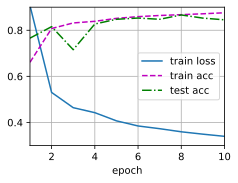

In [4]:
# 暂退法实现
import torch
from torch import nn
from d2l import torch as d2l


def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    # 在本情况中，所有元素都被丢弃
    if dropout == 1:
        return torch.zeros_like(X)
    # 在本情况中，所有元素都被保留
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)
# 暂退概率分别为0、0.5和1
# X= torch.arange(16, dtype = torch.float32).reshape((2, 8))
# print(X)
# print(dropout_layer(X, 0.))
# print(dropout_layer(X, 0.5))
# print(dropout_layer(X, 1.))
# Fashion-MNIST数据集，定义具有两个隐藏层的多层感知机
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

dropout1, dropout2 = 0.2, 0.5
# 暂退法应用于每个隐藏层的输出（在激活函数之后），靠近输入层的地方设置较低的暂退概率
class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只有在训练模型时才使用dropout
        if self.training == True:
            # 在第一个全连接层之后添加一个dropout层
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            # 在第二个全连接层之后添加一个dropout层
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out


net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

# 简洁实现。需在每个全连接层之后添加一个Dropout层， 将暂退概率作为唯一的参数传递给它的构造函数。 
# 在训练时，Dropout层将根据指定的暂退概率随机丢弃上一层的输出（相当于下一层的输入）。 在测试时，Dropout层仅传递数据。
net = nn.Sequential(nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        # 在第一个全连接层之后添加一个dropout层
        nn.Dropout(dropout1),
        nn.Linear(256, 256),
        nn.ReLU(),
        # 在第二个全连接层之后添加一个dropout层
        nn.Dropout(dropout2),
        nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);

trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

一个矩阵 
 tensor([[-1.4271, -0.1858, -1.3791, -2.3668],
        [-0.4540,  0.6039,  0.8218, -0.7281],
        [-0.2349, -0.3471, -1.4002, -0.0703],
        [ 0.7756,  0.8578, -0.4123,  0.0157]])
乘以100个矩阵后
 tensor([[ 8.4559e+22, -2.2474e+23,  3.2937e+22,  1.2634e+22],
        [ 3.8833e+22, -1.0321e+23,  1.5126e+22,  5.8022e+21],
        [-4.5259e+22,  1.2029e+23, -1.7628e+22, -6.7624e+21],
        [-2.9863e+23,  7.9371e+23, -1.1632e+23, -4.4619e+22]])


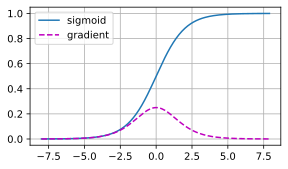

In [3]:
%matplotlib inline
import torch
from d2l import torch as d2l

x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.sigmoid(x)
y.backward(torch.ones_like(x))

d2l.plot(x.detach().numpy(), [y.detach().numpy(), x.grad.numpy()],
         legend=['sigmoid', 'gradient'], figsize=(4.5, 2.5))

# 梯度爆炸
M = torch.normal(0, 1, size=(4,4))
print('一个矩阵 \n',M)
for i in range(100):
    M = torch.mm(M,torch.normal(0, 1, size=(4, 4)))

print('乘以100个矩阵后\n', M)